In [2]:
import numpy as np
 
rng = np.random.RandomState(1)
data = np.linspace(start=0, stop=30, num=1_000).reshape(-1,1)
target = np.sin(data).ravel()


Random set of numbers from seed 0. Generate a evenly spaced data set from 0 to 30 with 1000 data points and put them in a 1000x1 (rowsxcolumns) array. then set a variable to be what we want the data to look like (which is a sine curve). Data is x variable and target is the y variable.

In [3]:
training_sample_indices = rng.choice(np.arange(0,400), size=40, replace=False)
training_data = data[training_sample_indices]
training_noisy_target = target[training_sample_indices] + 0.5 * rng.randn(
    len(training_sample_indices)
)

np.arange creates indices for each of the first 400 data points rather than leaving them as non integer x values (essentially they are the row numbers) - remember there are 1000 x values. rng.choice chooses 40 of those randomly (size=40). Replace=False just means that you dont pick the same one twice (like taking an already selected marble out of the bag). then in training_data = data[training_sample_indices] we use this to refer to the actual values, not the indices eg data[15] might be 1.23. The first part of the next line does the same thing for the y values then adds on a random number from a normal distribution randn (average=0 std=1), this is to add noise. len(training_sample_indices) returns 40, the number of numbers that raining_smaples_indices contains. (creates 40 random noise values)

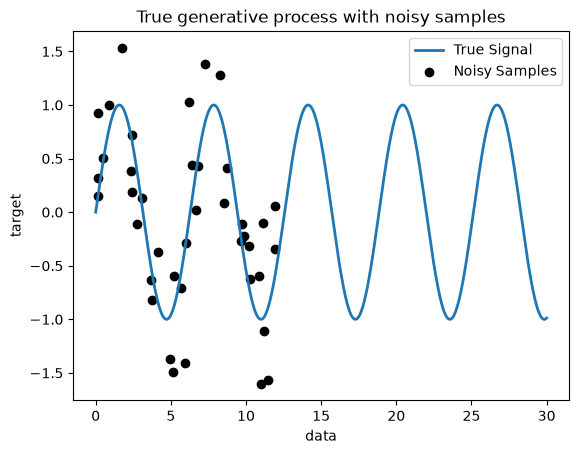

In [4]:
import matplotlib.pyplot as plt

plt.plot(data, target, label="True Signal", linewidth=2)
plt.scatter(training_data, training_noisy_target, color="black", label="Noisy Samples")
plt.xlabel("data")
plt.ylabel("target")
plt.legend()
_ = plt.title("True generative process with noisy samples")

In [5]:
import time
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared
kernel = 1.0 * ExpSineSquared(1.0, 5.0, periodicity_bounds=(1e-2, 1e1)) + 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
start_time=time.time()
gaussian_process.fit(training_data, training_noisy_target)
mean_predictions_gpr, std_predictions_gpr = gaussian_process.predict(data, return_std=True)

print(
    f"Time for Fitting: {time.time()-start_time} seconds"
)
gaussian_process.kernel

Time for Fitting: 0.25925493240356445 seconds


/Users/emilechhowalla/Downloads/Internship Zhejiang/AI Project/Coding/scientific-env/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/emilechhowalla/Downloads/Internship Zhejiang/AI Project/Coding/scientific-env/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


1**2 * ExpSineSquared(length_scale=1, periodicity=5) + 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)

This just adds the kernels. This one tests a exponential sine curve kernel because the data is like that of a sine curve. the white kernel is to deal with the noise and the rbf kernel is generally good at smoothing. it is optimised over 10 trials total. I am also checking the time of the process as a measure of processing required. And looking at the kernel parameters. I figure that the fitting wont be great as I think that the ideal periodicity of the ExpSineSquared Kernel should have ~2pi periodicity shown in its hyperparameter readout but it is 5 so its not optimised (unless the white and rbf kernels are negatively affecting it). 


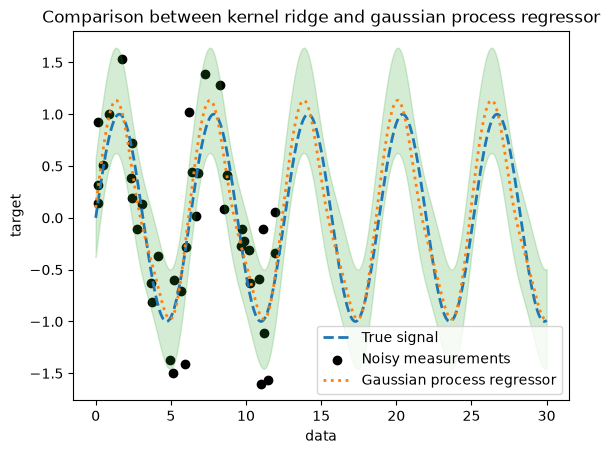

In [6]:
plt.plot(data, target, label="True signal", linewidth=2, linestyle="dashed")
plt.scatter(
    training_data,
    training_noisy_target,
    color="black",
    label="Noisy measurements",
)
# Plot the predictions of the gaussian process regressor
plt.plot(
    data,
    mean_predictions_gpr,
    label="Gaussian process regressor",
    linewidth=2,
    linestyle="dotted",
)
plt.fill_between(
    data.ravel(),
    mean_predictions_gpr - std_predictions_gpr,
    mean_predictions_gpr + std_predictions_gpr,
    color="tab:green",
    alpha=0.2,
)
plt.legend(loc="lower right")
plt.xlabel("data")
plt.ylabel("target")
_ = plt.title("Comparison between kernel ridge and gaussian process regressor")

This is just plotting. It is fairly accurate. I will try below with no rbf kernel.

Time for Fitting: 0.09938716888427734 seconds


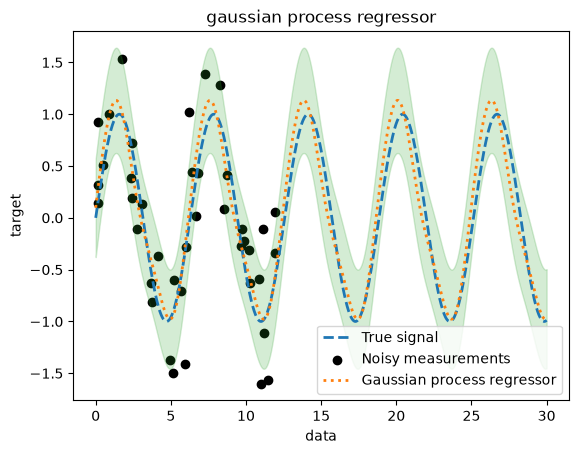

In [7]:
import time
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared
kernel = 1.0 * ExpSineSquared(1.0, 5.0, periodicity_bounds=(1e-2, 1e1)) + WhiteKernel(noise_level=1)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
start_time=time.time()
gaussian_process.fit(training_data, training_noisy_target)
mean_predictions_gpr, std_predictions_gpr = gaussian_process.predict(data, return_std=True)

print(
    f"Time for Fitting: {time.time()-start_time} seconds"
)
gaussian_process.kernel
plt.plot(data, target, label="True signal", linewidth=2, linestyle="dashed")
plt.scatter(
    training_data,
    training_noisy_target,
    color="black",
    label="Noisy measurements",
)
# Plot the predictions of the gaussian process regressor
plt.plot(
    data,
    mean_predictions_gpr,
    label="Gaussian process regressor",
    linewidth=2,
    linestyle="dotted",
)
plt.fill_between(
    data.ravel(),
    mean_predictions_gpr - std_predictions_gpr,
    mean_predictions_gpr + std_predictions_gpr,
    color="tab:green",
    alpha=0.2,
)
plt.legend(loc="lower right")
plt.xlabel("data")
plt.ylabel("target")
_ = plt.title("gaussian process regressor")

The RBF kernel didnt seem to have much effect.